In [1]:
!env | grep TPU

TPU_CHIPS_PER_HOST_BOUNDS=2,4,1
XRT_TPU_CONFIG=localservice;0;localhost:51011
TPU_SKIP_MDS_QUERY=1
TPU_RUNTIME_METRICS_PORTS=8431,8432,8433,8434,8435,8436,8437,8438
TPU_WORKER_ID=0
ISTPUVM=1
PJRT_DEVICE=TPU
TPU_WORKER_HOSTNAMES=localhost
TPU_ACCELERATOR_TYPE=v5litepod-8
TPU_HOST_BOUNDS=1,1,1
TPU_PROCESS_ADDRESSES=local


In [2]:
!python -c "import jax; [print(f'TPU {d.id} | Used Memory: {d.memory_stats().get(\"bytes_in_use\", 0)/1024**3:.2f} GB / Total Memory: {d.memory_stats().get(\"bytes_limit\", 1)/1024**3:.2f} GB') for d in jax.devices()]"

/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
E0000 00:00:1774428686.754054    1267 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:238
TPU 0 | Used Memory: 0.00 GB / Total Memory: 15.75 GB
TPU 1 | Used Memory: 0.00 GB / Total Memory: 15.75 GB
TPU 2 | Used Memory: 0.00 GB / Total Memory: 15.75 GB
TPU 3 | Used Memory: 0.00 GB / Total Memory: 15.75 GB
TPU 4 | Used Memory: 0.00 GB / Total Memory: 15.75 GB
TPU 5 | Used Memory: 0.00 GB / Total Memory: 15.75 

In [3]:
import os
# CRITICAL: Prevent JAX from pre-allocating all TPU memory!
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
import jax.numpy as jnp
import optax
import numpy as np
import functools
from flax.training import train_state
from flax import jax_utils
from diffusers import FlaxUNet2DConditionModel, FlaxDDPMScheduler, FlaxAutoencoderKL
from transformers import CLIPTokenizer, FlaxCLIPTextModel
from datasets import load_dataset
from huggingface_hub import login
import argparse

def get_hf_token():
    """Attempts to read the Hugging Face token from Kaggle Secrets, then local properties."""
    # 1. First, try to get the token from Kaggle Secrets
    try:
        from kaggle_secrets import UserSecretsClient
        user_secrets = UserSecretsClient()
        token = user_secrets.get_secret("HF_TOKEN")
        if token:
            print("Successfully loaded HF_TOKEN from Kaggle Secrets.")
            return token
    except Exception as e:
        print("Kaggle Secrets not available or HF_TOKEN not found. Trying settings.properties...")

    # 2. Fallback to settings.properties if Kaggle Secrets fails
    filepath = "settings.properties"
    if os.path.exists(filepath):
        with open(filepath, "r") as f:
            for line in f:
                line = line.strip()
                # Ignore empty lines and comments
                if line and not line.startswith("#"):
                    if "=" in line:
                        key, value = line.split("=", 1)
                        if key.strip().upper() == "HF_TOKEN":
                            print("Successfully loaded HF_TOKEN from settings.properties.")
                            return value.strip()
    return ""

# ==========================================
# 1. Configuration & Hyperparameters
# ==========================================
class TrainConfig:
    pretrained_model_name_or_path = "runwayml/stable-diffusion-v1-5"
    
    # Using Naruto dataset instead! It has the exact same structure.
    dataset_name = "lambdalabs/naruto-blip-captions"
    
    # Read your Hugging Face token automatically
    hf_token = get_hf_token() 
    
    # On Kaggle TPU v5e-8, there are 8 cores. Batch size must be divisible by device count.
    batch_size = 8 
    learning_rate = 1e-4
    num_train_steps = 50 # 50 steps is enough to see the loss drop for a sanity check
    seed = 42
    
    # Using 8 samples instead of 5 because we have 8 TPU cores. 
    # Data size must be divisible by the global batch size (8).
    num_samples_to_test = 8 

config = TrainConfig()

# Automatically login to Hugging Face if a token is provided
if config.hf_token:
    print("Logging into Hugging Face Hub...")
    login(token=config.hf_token)
else:
    print("WARNING: No HF token provided. Dataset download might fail if it's gated.")

# ==========================================
# 2. Load Real Dataset (Naruto)
# ==========================================
def load_real_dataset(dataset_name, num_samples, hf_token=None):
    """
    Downloads the image dataset from Hugging Face and extracts a small subset for testing.
    """
    print(f"Downloading and loading '{dataset_name}' from Hugging Face...")
    # Load the training split (pass token explicitly to avoid gated dataset errors)
    dataset = load_dataset(dataset_name, split="train", token=hf_token)
    
    # Select only the first 'num_samples' for our quick test
    dataset = dataset.select(range(num_samples))
    
    processed_dataset = []
    print(f"Processing {num_samples} images (Resizing to 512x512 and converting to RGB)...")
    
    for i, item in enumerate(dataset):
        # The dataset provides a PIL Image in the "image" column and text in "text"
        img = item["image"]
        caption = item["text"]
        
        # Ensure image is RGB (removes alpha channel if PNG) and resize to 512x512
        img = img.convert("RGB").resize((512, 512))
        
        processed_dataset.append({"image": img, "text": caption})
        print(f"Sample {i+1} caption: '{caption}'")
        
    return processed_dataset

# ==========================================
# 3. Preprocess Data (Extract Latents & Embeddings)
# ==========================================
def prepare_dataset_features(dataset, model_path):
    print("Loading VAE and Text Encoder on CPU to prevent TPU OOM...")
    
    # Load VAE and Text Encoder entirely on the CPU!
    cpu_device = jax.devices("cpu")[0]
    
    with jax.default_device(cpu_device):
        tokenizer = CLIPTokenizer.from_pretrained(model_path, subfolder="tokenizer")
        text_encoder = FlaxCLIPTextModel.from_pretrained(model_path, subfolder="text_encoder", dtype=jnp.float32, from_pt=True)
        vae, vae_params = FlaxAutoencoderKL.from_pretrained(model_path, subfolder="vae", dtype=jnp.float32, from_pt=True)
        
        all_latents = []
        all_embeddings = []
        
        for item in dataset:
            # Encode Text
            text_inputs = tokenizer(
                item["text"], max_length=tokenizer.model_max_length, padding="max_length", truncation=True, return_tensors="np"
            )
            text_embeds = text_encoder(text_inputs.input_ids)[0]
            all_embeddings.append(np.array(text_embeds))
            
            # Encode Image
            img_np = np.array(item["image"]).astype(np.float32) / 127.5 - 1.0
            img_np = np.transpose(img_np, (2, 0, 1))[None, ...] 
            
            vae_outputs = vae.apply({"params": vae_params}, img_np, method=vae.encode)
            latents = vae_outputs.latent_dist.sample(jax.random.PRNGKey(0))
            latents = jnp.transpose(latents, (0, 3, 1, 2))
            latents = latents * vae.config.scaling_factor
            
            all_latents.append(np.array(latents))
            
        latents_array = np.concatenate(all_latents, axis=0)
        embeddings_array = np.concatenate(all_embeddings, axis=0)
        
    print(f"Extracted Latents shape: {latents_array.shape}")
    print(f"Extracted Embeddings shape: {embeddings_array.shape}")
    
    # Free up CPU memory
    import gc
    del vae, vae_params, text_encoder, tokenizer, all_latents, all_embeddings
    gc.collect()
    
    return latents_array, embeddings_array

# ==========================================
# 4. Initialize UNet and Scheduler
# ==========================================
print("Initializing Scheduler...")
noise_scheduler, noise_scheduler_state = FlaxDDPMScheduler.from_pretrained(
    config.pretrained_model_name_or_path, subfolder="scheduler"
)

print("Initializing UNet and Optimizer on CPU first to prevent TPU OOM...")
cpu_device = jax.devices("cpu")[0]

# Load UNet on CPU first
with jax.default_device(cpu_device):
    unet, unet_params = FlaxUNet2DConditionModel.from_pretrained(
        config.pretrained_model_name_or_path, subfolder="unet", dtype=jnp.bfloat16, from_pt=True
    )

    # Adafactor optimizer to save huge TPU memory
    tx = optax.adafactor(
        learning_rate=config.learning_rate,
        multiply_by_parameter_scale=False
    )

    state = train_state.TrainState.create(
        apply_fn=unet.apply,
        params=unet_params,
        tx=tx,
    )

# ==========================================
# 5. Replicate State for TPU Parallelism
# ==========================================
num_devices = jax.device_count()
print(f"Replicating clean model parameters to {num_devices} TPU cores...")
state = jax_utils.replicate(state)

# ==========================================
# 6. Define PMAP-compiled Train Step (TPU Parallelism)
# ==========================================
@functools.partial(jax.pmap, axis_name='batch')
def train_step(state, batch_latents, batch_embeddings, train_rng):
    sample_rng, timestep_rng = jax.random.split(train_rng, 2)

    def compute_loss(params):
        noise = jax.random.normal(sample_rng, batch_latents.shape)
        bsz = batch_latents.shape[0]
        timesteps = jax.random.randint(
            timestep_rng, (bsz,), 0, noise_scheduler.config.num_train_timesteps,
        )

        noisy_latents = noise_scheduler.add_noise(
            noise_scheduler_state, batch_latents, noise, timesteps
        )

        noisy_latents_bf16 = noisy_latents.astype(jnp.bfloat16)
        batch_embeddings_bf16 = batch_embeddings.astype(jnp.bfloat16)

        model_pred = unet.apply(
            {"params": params},
            noisy_latents_bf16,
            timesteps,
            batch_embeddings_bf16,
        ).sample

        loss = jnp.mean((model_pred.astype(jnp.float32) - noise) ** 2)
        return loss

    grad_fn = jax.value_and_grad(compute_loss)
    loss, grads = grad_fn(state.params)
    
    grads = jax.lax.pmean(grads, axis_name='batch')
    loss = jax.lax.pmean(loss, axis_name='batch')
    
    state = state.apply_gradients(grads=grads)
    return state, loss

# ==========================================
# 7. Main Training Loop
# ==========================================
if __name__ == "__main__":
    # Load Real Dataset instead of synthetic, passing the token explicitly
    raw_dataset = load_real_dataset(config.dataset_name, config.num_samples_to_test, config.hf_token)
    train_latents, train_embeddings = prepare_dataset_features(raw_dataset, config.pretrained_model_name_or_path)
    
    print(f"Starting training loop on {num_devices} TPU cores...")
    rng = jax.random.PRNGKey(config.seed)
    
    num_batches = len(train_latents) // config.batch_size
    batch_size_per_device = config.batch_size // num_devices
    
    for step in range(config.num_train_steps):
        rng, step_rng = jax.random.split(rng, 2)
        step_rngs = jax.random.split(step_rng, num_devices)
        
        batch_idx = step % num_batches
        start_idx = batch_idx * config.batch_size
        end_idx = start_idx + config.batch_size
        
        b_latents = train_latents[start_idx:end_idx]
        b_embeddings = train_embeddings[start_idx:end_idx]
        
        b_latents = b_latents.reshape((num_devices, batch_size_per_device) + b_latents.shape[1:])
        b_embeddings = b_embeddings.reshape((num_devices, batch_size_per_device) + b_embeddings.shape[1:])
        
        state, loss = train_step(state, b_latents, b_embeddings, step_rngs)
        
        if step % 10 == 0 or step == config.num_train_steps - 1:
            print(f"Step {step:04d} | Loss: {jax.device_get(loss[0]):.4f}")

    print("Training finished successfully!")
    
    # state_to_save = jax_utils.unreplicate(state)
    # from flax.training import checkpoints
    # checkpoints.save_checkpoint(ckpt_dir="/kaggle/working/model_naruto", target=state_to_save, step=config.num_train_steps, keep=1)
    # print("Model weights successfully saved to /kaggle/working/model_naruto !")

    from flax.training import checkpoints
    from flax import jax_utils

    unreplicated = jax_utils.unreplicate(state)

    # Save only the UNet params (already bfloat16 from training),
    # not the full TrainState — inference only needs the weights,
    # not the optimizer state or step counter.
    unet_params_to_save = jax.tree_util.tree_map(
        lambda x: x.astype(jnp.bfloat16),
        unreplicated.params
    )

    checkpoints.save_checkpoint(
        ckpt_dir="/kaggle/working/model_naruto",
        target={"params": unet_params_to_save},
        step=config.num_train_steps,
        keep=1,
        overwrite=True,
    )
    print("Model weights successfully saved to /kaggle/working/model_naruto !")

/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend mi

Successfully loaded HF_TOKEN from Kaggle Secrets.
Logging into Hugging Face Hub...
Initializing Scheduler...


scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
E0000 00:00:1774428719.637497    1249 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:238
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Initializing UNet and Optimizer on CPU first to prevent TPU OOM...


...

vae/diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch cla

Extracted Latents shape: (8, 4, 64, 64)
Extracted Embeddings shape: (8, 77, 768)
Starting training loop on 8 TPU cores...


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch cla

Step 0000 | Loss: 0.1488
Step 0010 | Loss: 0.0701
Step 0020 | Loss: 0.0601
Step 0030 | Loss: 0.0768
Step 0040 | Loss: 0.1269
Step 0049 | Loss: 0.0768
Training finished successfully!
Model weights successfully saved to /kaggle/working/model_naruto !


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


CPU: TFRT_CPU_0
TPU: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]
Loading base pipeline on CPU…


Fetching 29 files:   0%|          | 0/29 [00:00<?, ?it/s]

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch cla

Replacing base UNet with fine-tuned Naruto weights…
Verifying component dtypes…
  Casting scheduler: float32 → bfloat16
  Casting vae: float32 → bfloat16
  Casting text_encoder: float32 → bfloat16
  unet: bfloat16 ✓
Replicating parameters to TPU core 0…
  → scheduler
  → vae
  → text_encoder
  → unet
All parameters on TPU.

Prompt: 'A drawing of Naruto Uzumaki'


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch cla

Transferring result to host…
Done!


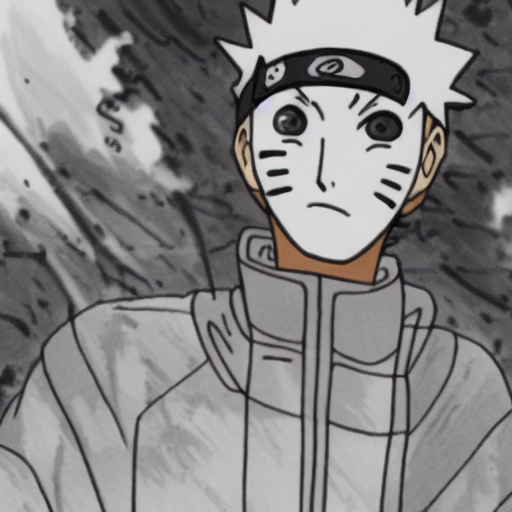

In [5]:
import os
# CRITICAL: Must be set before importing JAX.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]   = "platform"

import gc

import jax
import jax.numpy as jnp
import numpy as np
from diffusers import FlaxStableDiffusionPipeline
from flax import jax_utils
from flax.core import freeze, unfreeze
from flax.training import checkpoints
from IPython.display import display

# ──────────────────────────────────────────────────────────────────────────────
# Device setup — use only 1 TPU core for single-image inference.
# Using all 8 cores would force jax_utils.replicate() to create 8 copies of
# every parameter tensor in CPU RAM before the first tensor reaches the TPU.
# ──────────────────────────────────────────────────────────────────────────────
cpu_device = jax.devices("cpu")[0]
single_tpu = jax.devices()[:1]

print(f"CPU: {cpu_device}")
print(f"TPU: {single_tpu}")

MODEL_ID       = "runwayml/stable-diffusion-v1-5"
CHECKPOINT_DIR = "/kaggle/working/model_naruto"

# ──────────────────────────────────────────────────────────────────────────────
# Step 1 — Load the base pipeline on CPU.
#
# dtype=bfloat16 halves every component's footprint versus float32.
# Loading on CPU keeps everything out of TPU HBM until we explicitly move it.
# ──────────────────────────────────────────────────────────────────────────────
print("Loading base pipeline on CPU…")
with jax.default_device(cpu_device):
    pipe, params = FlaxStableDiffusionPipeline.from_pretrained(
        MODEL_ID,
        dtype=jnp.bfloat16,
        from_pt=True,
        safety_checker=None,
    )

# ──────────────────────────────────────────────────────────────────────────────
# Step 2 — Swap in the fine-tuned UNet weights.
#
# The training script now saves ONLY the bfloat16 UNet params under the key
# "params", so:
#   raw_ckpt["params"]  →  the UNet weight pytree, already bfloat16.
#
# There is NO dtype cast needed here — the weights are already in the right
# format.  No float32 intermediate copy is ever created.
#
# Memory peak for this step:
#   base UNet (bfloat16) + fine-tuned UNet (bfloat16) simultaneously.
#   We minimise this window by deleting the base UNet before loading the ckpt.
# ──────────────────────────────────────────────────────────────────────────────
print("Replacing base UNet with fine-tuned Naruto weights…")
with jax.default_device(cpu_device):
    params = unfreeze(params)

    # Free the base UNet first so we never hold two UNets at once.
    del params["unet"]
    gc.collect()

    # Load the checkpoint.  target=None → raw dict, no pytree shape hint needed.
    raw_ckpt = checkpoints.restore_checkpoint(ckpt_dir=CHECKPOINT_DIR, target=None)

    # raw_ckpt["params"] is the bfloat16 UNet param tree saved by training.
    # No cast required — assign directly.
    params["unet"] = raw_ckpt["params"]

    del raw_ckpt
    gc.collect()

# ──────────────────────────────────────────────────────────────────────────────
# Step 3 — Verify dtypes for all components.
#
# from_pretrained with dtype=bfloat16 should have handled the base components,
# but we do a lightweight check here.  We ONLY cast if a component is not
# already bfloat16, avoiding the double-buffer spike for components that are
# already correct.
# ──────────────────────────────────────────────────────────────────────────────
print("Verifying component dtypes…")
with jax.default_device(cpu_device):
    for key in list(params.keys()):
        leaves = jax.tree_util.tree_leaves(params[key])
        if not leaves:
            continue
        actual_dtype = leaves[0].dtype
        if actual_dtype != jnp.bfloat16:
            print(f"  Casting {key}: {actual_dtype} → bfloat16")
            params[key] = jax.tree_util.tree_map(
                lambda x: x.astype(jnp.bfloat16), params[key]
            )
        else:
            print(f"  {key}: bfloat16 ✓")
    gc.collect()

# ──────────────────────────────────────────────────────────────────────────────
# Step 4 — Move parameters to the single TPU core.
#
# We process one component at a time.  After each replicate() call we call
# jax.block_until_ready() to force XLA to complete the DMA transfer before
# we delete the CPU-side source.  Without this, the async XLA runtime may hold
# a hidden reference and the CPU buffer will not be freed until much later.
# ──────────────────────────────────────────────────────────────────────────────
print("Replicating parameters to TPU core 0…")
p_params = {}
for key in list(params.keys()):
    print(f"  → {key}")
    p_params[key] = jax_utils.replicate(params[key], devices=single_tpu)
    jax.block_until_ready(p_params[key])   # wait for transfer to finish
    del params[key]
    gc.collect()

p_params = freeze(p_params)
print("All parameters on TPU.")

# ──────────────────────────────────────────────────────────────────────────────
# Step 5 — Run inference.
# ──────────────────────────────────────────────────────────────────────────────
PROMPT = "A drawing of Naruto Uzumaki"
print(f"\nPrompt: '{PROMPT}'")

prompts      = [PROMPT] * len(single_tpu)
prompt_ids   = pipe.prepare_inputs(prompts)
p_prompt_ids = jax_utils.replicate(prompt_ids, devices=single_tpu)
prng_seed    = jax.random.split(jax.random.PRNGKey(42), len(single_tpu))

output = pipe(
    prompt_ids=p_prompt_ids,
    params=p_params,
    prng_seed=prng_seed,
    num_inference_steps=50,
    jit=True,
)

# ──────────────────────────────────────────────────────────────────────────────
# Step 6 — Convert to PIL and display.
#
# output.images shape: (num_devices, batch_per_device, H, W, C)
#                    = (1, 1, 512, 512, 3) with our single-device setup.
#
# block_until_ready() ensures the TPU computation is complete before we
# initiate the device→host copy.  reshape(-1, H, W, C) collapses the
# leading (num_devices, batch) dims so numpy_to_pil gets the expected layout.
# ──────────────────────────────────────────────────────────────────────────────
print("Transferring result to host…")
jax.block_until_ready(output.images)

H, W, C    = output.images.shape[-3:]
images_np  = np.asarray(output.images.reshape(-1, H, W, C))
images_pil = pipe.numpy_to_pil(images_np)

print("Done!")
display(images_pil[0])